In [1]:
# Step 1- Import libraries

import numpy as np
import pandas as pd
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Step 2 - Load processed datasets

X_train = np.load("../processed_data/X_train_processed.npy")
X_validation = np.load("../processed_data/X_validation_processed.npy")
X_test = np.load("../processed_data/X_test_processed.npy")

y_train = pd.read_csv("../processed_data/y_train.csv").squeeze()
y_validation = pd.read_csv("../processed_data/y_validation.csv").squeeze()
y_test = pd.read_csv("../processed_data/y_test.csv").squeeze()

print("Training data:", X_train.shape, y_train.shape)
print("Validation data:", X_validation.shape, y_validation.shape)
print("Test data:", X_test.shape, y_test.shape)

Training data: (87963, 31) (87963,)
Validation data: (7385, 31) (7385,)
Test data: (4652, 31) (4652,)


In [3]:
# Step 3 - Check target distribution

print("Training target:")
print(y_train.describe())

print("\nValidation target:")
print(y_validation.describe())

print("\nTest target:")
print(y_test.describe())

Training target:
count    87963.000000
mean        10.035294
std          1.800573
min          0.000000
25%          9.870000
50%         10.200000
75%         10.900000
max         20.000000
Name: Dissolved Oxygen (mg/l), dtype: float64

Validation target:
count    7385.000000
mean        9.833187
std         2.208385
min         0.174000
25%         9.600000
50%        10.200000
75%        11.300000
max        19.900000
Name: Dissolved Oxygen (mg/l), dtype: float64

Test target:
count    4652.000000
mean        9.771287
std         2.199568
min         0.101000
25%         9.376000
50%        10.200000
75%        11.200000
max        18.750000
Name: Dissolved Oxygen (mg/l), dtype: float64


In [5]:
# Step 4 - Train Linear Regression baseline

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression trained successfully")

Linear Regression trained successfully


In [6]:
# Step 5 - Evaluate Linear Regression

linear_validation_pred = linear_model.predict(X_validation)

linear_mae = mean_absolute_error(
    y_validation,
    linear_validation_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        linear_validation_pred
    )
)

linear_r2 = r2_score(
    y_validation,
    linear_validation_pred
)

print("Linear Regression Validation Results")
print("-------------------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R2  :", linear_r2)

Linear Regression Validation Results
-------------------------------------
MAE : 1.3459823657218069
RMSE: 1.9670601567770878
R2  : 0.20650471992658104


In [7]:
# Step 6 - Train Random Forest

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


In [8]:
# Step 7 - Evaluate Random Forest

rf_validation_pred = rf_model.predict(X_validation)

rf_mae = mean_absolute_error(
    y_validation,
    rf_validation_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        rf_validation_pred
    )
)

rf_r2 = r2_score(
    y_validation,
    rf_validation_pred
)

print("Random Forest Validation Results")
print("---------------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Random Forest Validation Results
---------------------------------
MAE : 1.2425415663634758
RMSE: 1.9178675478782534
R2  : 0.245696217718955


In [9]:
# Step 8 - Train Gradient Boosting

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting trained successfully")

Gradient Boosting trained successfully


In [10]:
# Step 9 - Evaluate Gradient Boosting

gb_validation_pred = gb_model.predict(X_validation)

gb_mae = mean_absolute_error(
    y_validation,
    gb_validation_pred
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        gb_validation_pred
    )
)

gb_r2 = r2_score(
    y_validation,
    gb_validation_pred
)

print("Gradient Boosting Validation Results")
print("------------------------------------")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R2  :", gb_r2)

Gradient Boosting Validation Results
------------------------------------
MAE : 1.2617989650234038
RMSE: 1.8923676940643848
R2  : 0.265621227562722


In [11]:
# Step 10 - Compare models

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

model_results

,Model,MAE,RMSE,R2
0,Linear Regression,1.345982,1.967060,0.206505
1,Random Forest,1.242542,1.917868,0.245696
2,Gradient Boosting,1.261799,1.892368,0.265621


In [13]:
# Step 11 - Get actual feature names and feature importance

preprocessor = joblib.load(
    "../models/water_quality_preprocessor.joblib"
)

feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print("Number of model features:", len(rf_model.feature_importances_))

Number of feature names: 31
Number of model features: 31


In [14]:
# Step 12 - Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,num__Temperature (cel),0.223611
1,num__pH (ph units),0.120881
2,num__Ammonia (mg/l),0.092489
3,num__Nitrogen (mg/l),0.091831
4,num__Orthophosphate (mg/l),0.084275
5,num__Year,0.079116
6,num__Nitrate (mg/l),0.076495
7,cat__Country_Ireland,0.062083
8,num__Biochemical Oxygen Demand (mg/l),0.057962
9,num__Month,0.053720


In [16]:
import matplotlib.pyplot as plt

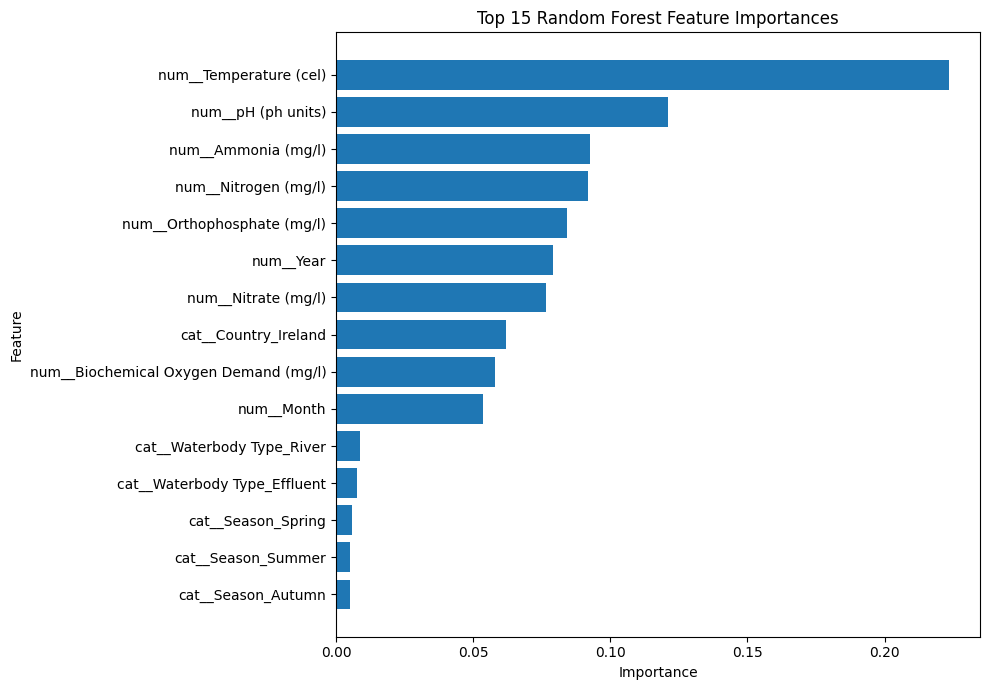

In [17]:
# Step 13 - Plot Random Forest feature importance

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

In [18]:
# Step 14 - Final Gradient Boosting evaluation on test data

gb_test_pred = gb_model.predict(X_test)

gb_test_mae = mean_absolute_error(
    y_test,
    gb_test_pred
)

gb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_test_pred
    )
)

gb_test_r2 = r2_score(
    y_test,
    gb_test_pred
)

print("Gradient Boosting Test Results")
print("--------------------------------")
print("MAE :", gb_test_mae)
print("RMSE:", gb_test_rmse)
print("R2  :", gb_test_r2)

Gradient Boosting Test Results
--------------------------------
MAE : 1.2923963601937112
RMSE: 1.9092009177292861
R2  : 0.24643275578479262


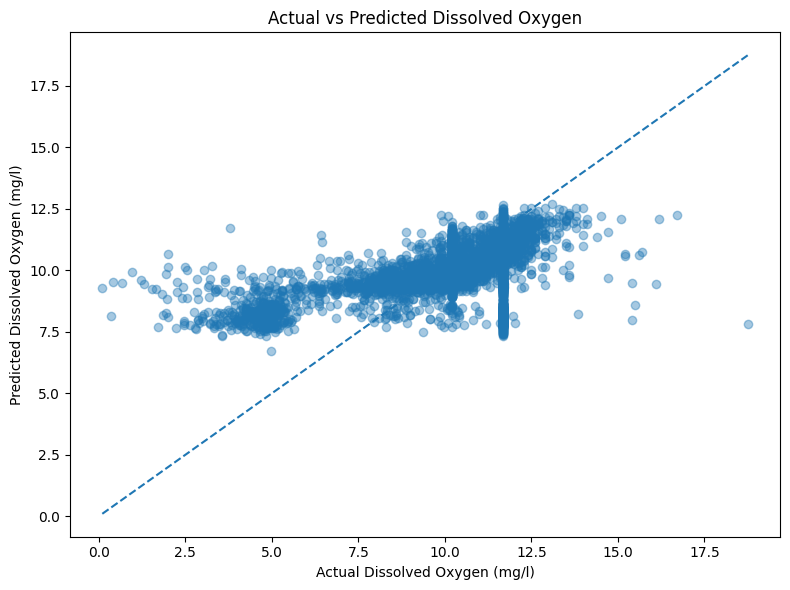

In [19]:
# Step 15 - Actual vs Predicted Dissolved Oxygen

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    gb_test_pred,
    alpha=0.4
)

# Perfect prediction line
min_value = min(y_test.min(), gb_test_pred.min())
max_value = max(y_test.max(), gb_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Dissolved Oxygen (mg/l)")
plt.ylabel("Predicted Dissolved Oxygen (mg/l)")
plt.title("Actual vs Predicted Dissolved Oxygen")

plt.tight_layout()
plt.show()

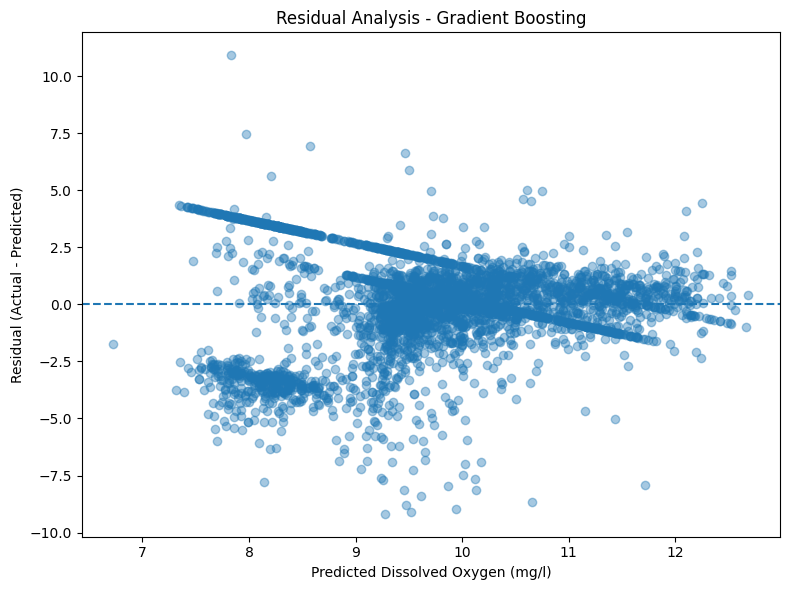

In [20]:
# Step 16 - Prediction residuals

residuals = y_test - gb_test_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    gb_test_pred,
    residuals,
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Dissolved Oxygen (mg/l)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis - Gradient Boosting")

plt.tight_layout()
plt.show()

In [21]:
# Step 17 - Save final Gradient Boosting model

import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    gb_model,
    "../models/water_quality_gradient_boosting_model.joblib"
)

print("Gradient Boosting model saved successfully.")

Gradient Boosting model saved successfully.


In [22]:
# Step 18 - Save model performance results

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Validation_MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "Validation_RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    "Validation_R2": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

# Add final test performance for Gradient Boosting
test_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Test_Value": [
        gb_test_mae,
        gb_test_rmse,
        gb_test_r2
    ]
})

os.makedirs("../processed_data", exist_ok=True)

results.to_csv(
    "../processed_data/model_validation_results.csv",
    index=False
)

test_results.to_csv(
    "../processed_data/gradient_boosting_test_results.csv",
    index=False
)

print("Model results saved successfully.")

print("\nValidation Results:")
print(results)

print("\nFinal Test Results:")
print(test_results)

Model results saved successfully.

Validation Results:
               Model  Validation_MAE  Validation_RMSE  Validation_R2
0  Linear Regression        1.345982         1.967060       0.206505
1      Random Forest        1.242542         1.917868       0.245696
2  Gradient Boosting        1.261799         1.892368       0.265621

Final Test Results:
  Metric  Test_Value
0    MAE    1.292396
1   RMSE    1.909201
2     R2    0.246433


In [23]:
# Step 19 - Save Random Forest feature importance

feature_importance.to_csv(
    "../processed_data/random_forest_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")
print(feature_importance.head(15))

Feature importance saved successfully.
                                  Feature  Importance
0                  num__Temperature (cel)    0.223611
1                      num__pH (ph units)    0.120881
2                     num__Ammonia (mg/l)    0.092489
3                    num__Nitrogen (mg/l)    0.091831
4              num__Orthophosphate (mg/l)    0.084275
5                               num__Year    0.079116
6                     num__Nitrate (mg/l)    0.076495
7                    cat__Country_Ireland    0.062083
8   num__Biochemical Oxygen Demand (mg/l)    0.057962
9                              num__Month    0.053720
10              cat__Waterbody Type_River    0.008788
11           cat__Waterbody Type_Effluent    0.007771
12                     cat__Season_Spring    0.005748
13                     cat__Season_Summer    0.005133
14                     cat__Season_Autumn    0.005068


In [24]:
# Step 20 - Save test predictions

prediction_results = pd.DataFrame({
    "Actual_DO": y_test.values,
    "Predicted_DO": gb_test_pred,
    "Residual": residuals.values
})

prediction_results.to_csv(
    "../processed_data/test_predictions.csv",
    index=False
)

print("Test predictions saved successfully.")
print(prediction_results.head(10))

Test predictions saved successfully.
   Actual_DO  Predicted_DO  Residual
0  10.200000      9.654579  0.545421
1   4.450500      8.742439 -4.291939
2  10.400000      9.946312  0.453688
3  10.200000     10.203023 -0.003023
4  10.200000     10.499615 -0.299615
5   9.680000      9.509896  0.170104
6  16.200000     12.100135  4.099865
7  11.684103     11.676668  0.007435
8   9.940000     10.441822 -0.501822
9   9.760000      9.664114  0.095886


In [25]:
# Step 21 - Save final model information

import json

model_info = {
    "model": "Gradient Boosting Regressor",
    "target": "Dissolved Oxygen (mg/l)",
    "test_mae": float(gb_test_mae),
    "test_rmse": float(gb_test_rmse),
    "test_r2": float(gb_test_r2),
    "number_of_features": int(X_train.shape[1]),
    "training_samples": int(X_train.shape[0]),
    "validation_samples": int(X_validation.shape[0]),
    "test_samples": int(X_test.shape[0])
}

with open(
    "../models/water_quality_model_info.json",
    "w"
) as f:
    json.dump(model_info, f, indent=4)

print("Model information saved successfully.")
print(json.dumps(model_info, indent=4))

Model information saved successfully.
{
    "model": "Gradient Boosting Regressor",
    "target": "Dissolved Oxygen (mg/l)",
    "test_mae": 1.2923963601937112,
    "test_rmse": 1.9092009177292861,
    "test_r2": 0.24643275578479262,
    "number_of_features": 31,
    "training_samples": 87963,
    "validation_samples": 7385,
    "test_samples": 4652
}


In [26]:
# Step 22 - Verify saved model files

import os

required_files = [
    "../models/water_quality_preprocessor.joblib",
    "../models/water_quality_gradient_boosting_model.joblib",
    "../models/water_quality_model_info.json",
    "../processed_data/model_validation_results.csv",
    "../processed_data/gradient_boosting_test_results.csv",
    "../processed_data/random_forest_feature_importance.csv",
    "../processed_data/test_predictions.csv"
]

print("Saved files verification")
print("------------------------")

for file in required_files:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗ MISSING:", file)

Saved files verification
------------------------
✓ ../models/water_quality_preprocessor.joblib
✓ ../models/water_quality_gradient_boosting_model.joblib
✓ ../models/water_quality_model_info.json
✓ ../processed_data/model_validation_results.csv
✓ ../processed_data/gradient_boosting_test_results.csv
✓ ../processed_data/random_forest_feature_importance.csv
✓ ../processed_data/test_predictions.csv


In [27]:
# Step 23 - Load final model and preprocessor

import joblib

final_model = joblib.load(
    "../models/water_quality_gradient_boosting_model.joblib"
)

final_preprocessor = joblib.load(
    "../models/water_quality_preprocessor.joblib"
)

print("Final model loaded successfully.")
print("Preprocessor loaded successfully.")

Final model loaded successfully.
Preprocessor loaded successfully.


In [28]:
# Step 24 - Predict dissolved oxygen for a new observation

new_data = pd.DataFrame({
    "Country": ["England"],
    "Waterbody Type": ["River"],
    "Ammonia (mg/l)": [0.5],
    "Biochemical Oxygen Demand (mg/l)": [3.0],
    "Orthophosphate (mg/l)": [0.1],
    "pH (ph units)": [7.5],
    "Temperature (cel)": [15.0],
    "Nitrogen (mg/l)": [3.0],
    "Nitrate (mg/l)": [4.0],
    "Year": [2023],
    "Month": [6],
    "Season": ["Summer"],
    "Temperature_Extreme": [0]
})

print("New observation:")
print(new_data)

New observation:
   Country Waterbody Type  Ammonia (mg/l)  Biochemical Oxygen Demand (mg/l)  \
0  England          River             0.5                               3.0   

   Orthophosphate (mg/l)  pH (ph units)  Temperature (cel)  Nitrogen (mg/l)  \
0                    0.1            7.5               15.0              3.0   

   Nitrate (mg/l)  Year  Month  Season  Temperature_Extreme  
0             4.0  2023      6  Summer                    0  


In [29]:
# Step 24 - Preprocess and predict

new_data_processed = final_preprocessor.transform(new_data)

prediction = final_model.predict(new_data_processed)

print("Predicted Dissolved Oxygen:", prediction[0], "mg/l")

Predicted Dissolved Oxygen: 9.369952123387721 mg/l


In [30]:
# Step 25 - Create reusable prediction function

def predict_dissolved_oxygen(input_data):
    
    input_df = pd.DataFrame([input_data])
    
    processed_data = final_preprocessor.transform(input_df)
    
    prediction = final_model.predict(processed_data)
    
    return prediction[0]


print("Prediction function created successfully.")

Prediction function created successfully.


In [31]:
sample_input = {
    "Country": "England",
    "Waterbody Type": "River",
    "Ammonia (mg/l)": 0.5,
    "Biochemical Oxygen Demand (mg/l)": 3.0,
    "Orthophosphate (mg/l)": 0.1,
    "pH (ph units)": 7.5,
    "Temperature (cel)": 15.0,
    "Nitrogen (mg/l)": 3.0,
    "Nitrate (mg/l)": 4.0,
    "Year": 2023,
    "Month": 6,
    "Season": "Summer",
    "Temperature_Extreme": 0
}

result = predict_dissolved_oxygen(sample_input)

print("Predicted Dissolved Oxygen:", result, "mg/l")

Predicted Dissolved Oxygen: 9.369952123387721 mg/l


In [32]:
# Step 26 - Baseline model comparison

baseline_prediction = np.full(
    len(y_test),
    y_train.mean()
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_prediction
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_prediction
)

print("Baseline Test Results")
print("---------------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R2  :", baseline_r2)

print("\nGradient Boosting Test Results")
print("------------------------------")
print("MAE :", gb_test_mae)
print("RMSE:", gb_test_rmse)
print("R2  :", gb_test_r2)

Baseline Test Results
---------------------
MAE : 1.4445340143184888
RMSE: 2.215120192798641
R2  : -0.014409565324313256

Gradient Boosting Test Results
------------------------------
MAE : 1.2923963601937112
RMSE: 1.9092009177292861
R2  : 0.24643275578479262


In [33]:
# Step 27 - Try improved Gradient Boosting configurations

gb_configs = [
    {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 3
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 3
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 4
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 4
    }
]

tuning_results = []

for config in gb_configs:

    model = GradientBoostingRegressor(
        n_estimators=config["n_estimators"],
        learning_rate=config["learning_rate"],
        max_depth=config["max_depth"],
        random_state=42
    )

    model.fit(X_train, y_train)

    validation_pred = model.predict(X_validation)

    mae = mean_absolute_error(
        y_validation,
        validation_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            validation_pred
        )
    )

    r2 = r2_score(
        y_validation,
        validation_pred
    )

    tuning_results.append({
        "n_estimators": config["n_estimators"],
        "learning_rate": config["learning_rate"],
        "max_depth": config["max_depth"],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

tuning_results = pd.DataFrame(tuning_results)

tuning_results.sort_values(
    by="RMSE",
    ascending=True
)

,n_estimators,learning_rate,max_depth,MAE,RMSE,R2
3,300,0.05,4,1.257419,1.890095,0.267384
2,200,0.05,4,1.261799,1.892368,0.265621
1,300,0.05,3,1.268826,1.895186,0.263432
0,300,0.03,3,1.274275,1.900217,0.259516


In [34]:
# Step 28 - Select best tuned Gradient Boosting configuration

best_config = tuning_results.sort_values(
    by="RMSE",
    ascending=True
).iloc[0]

print("Best configuration:")
print(best_config)

Best configuration:
n_estimators     300.000000
learning_rate      0.050000
max_depth          4.000000
MAE                1.257419
RMSE               1.890095
R2                 0.267384
Name: 3, dtype: float64


In [35]:
# Step 28 - Train final tuned model

tuned_gb_model = GradientBoostingRegressor(
    n_estimators=int(best_config["n_estimators"]),
    learning_rate=float(best_config["learning_rate"]),
    max_depth=int(best_config["max_depth"]),
    random_state=42
)

tuned_gb_model.fit(
    X_train,
    y_train
)

print("Tuned Gradient Boosting model trained successfully.")

Tuned Gradient Boosting model trained successfully.


In [36]:
# Step 29 - Final test evaluation of tuned model

tuned_test_pred = tuned_gb_model.predict(X_test)

tuned_test_mae = mean_absolute_error(
    y_test,
    tuned_test_pred
)

tuned_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_test_pred
    )
)

tuned_test_r2 = r2_score(
    y_test,
    tuned_test_pred
)

print("Tuned Gradient Boosting Test Results")
print("------------------------------------")
print("MAE :", tuned_test_mae)
print("RMSE:", tuned_test_rmse)
print("R2  :", tuned_test_r2)

Tuned Gradient Boosting Test Results
------------------------------------
MAE : 1.2889659777343907
RMSE: 1.9053208118135252
R2  : 0.2494926218520962


In [37]:
# Step 30 - Compare original and tuned model

final_comparison = pd.DataFrame({
    "Model": [
        "Original Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "MAE": [
        gb_test_mae,
        tuned_test_mae
    ],
    "RMSE": [
        gb_test_rmse,
        tuned_test_rmse
    ],
    "R2": [
        gb_test_r2,
        tuned_test_r2
    ]
})

final_comparison

,Model,MAE,RMSE,R2
0,Original Gradient Boosting,1.292396,1.909201,0.246433
1,Tuned Gradient Boosting,1.288966,1.905321,0.249493
